In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

2026-02-26 09:30:31.745669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772098231.940259      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772098231.995125      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772098232.448896      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772098232.448940      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772098232.448942      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [5]:
# Load MNIST
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Normalize
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten
X_train_full = X_train_full.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encoding
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_mlp():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [8]:
from tensorflow.keras.optimizers import SGD

model_sgd = build_mlp()
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=1,
    verbose=1
)
time_sgd = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772098257.448835      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1772098259.545348      64 service.cc:152] XLA service 0x7958e8006900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772098259.545377      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772098259.705734      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


   78/48000 ━━━━━━━━━━━━━━━━━━━━ 1:35 2ms/step - accuracy: 0.1223 - loss: 2.3228

I0000 00:00:1772098260.190318      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48000/48000 ━━━━━━━━━━━━━━━━━━━━ 112s 2ms/step - accuracy: 0.8744 - loss: 0.3964 - val_accuracy: 0.9567 - val_loss: 0.1517
Epoch 2/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9649 - loss: 0.1124 - val_accuracy: 0.9653 - val_loss: 0.1167
Epoch 3/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9760 - loss: 0.0778 - val_accuracy: 0.9688 - val_loss: 0.1051
Epoch 4/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9802 - loss: 0.0615 - val_accuracy: 0.9652 - val_loss: 0.1153
Epoch 5/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 111s 2ms/step - accuracy: 0.9843 - loss: 0.0506 - val_accuracy: 0.9721 - val_loss: 0.1033
Epoch 6/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 110s 2ms/step - accuracy: 0.9853 - loss: 0.0424 - val_accuracy: 0.9730 - val_loss: 0.1016
Epoch 7/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 113s 2ms/step - accuracy: 0.9895 - loss: 0.0317 - val_accuracy: 0.9764 - val_loss: 0.0953
Epoch 8/50
48000/48000 ━━━━━━━━━━━━━━━━━━━━ 120s 3ms/step - accuracy: 0.9

4.2 Mini-Batch SGD (batch = 64) ⭐ BEST PRACTICE

In [9]:
model_mini = build_mlp()
model_mini.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_mini = model_mini.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)
time_mini = time.time() - start

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5510 - loss: 1.5333 - val_accuracy: 0.8767 - val_loss: 0.4729
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8841 - loss: 0.4325 - val_accuracy: 0.9032 - val_loss: 0.3482
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9028 - loss: 0.3395 - val_accuracy: 0.9147 - val_loss: 0.3045
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9153 - loss: 0.2964 - val_accuracy: 0.9221 - val_loss: 0.2779
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9219 - loss: 0.2748 - val_accuracy: 0.9253 - val_loss: 0.2589
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9297 - loss: 0.2463 - val_accuracy: 0.9315 - val_loss: 0.2441
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9323 - loss: 0.2385 - val_accuracy: 0.9342 - val_loss: 0.2321
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9394 - loss: 0.2150 - val_accuracy: 0.

In [10]:
model_batch = build_mlp()
model_batch.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_batch = model_batch.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=len(X_train),
    verbose=1
)
time_batch = time.time() - start

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0865 - loss: 2.3403 - val_accuracy: 0.0874 - val_loss: 2.3310
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.0890 - loss: 2.3294 - val_accuracy: 0.0889 - val_loss: 2.3205
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.0919 - loss: 2.3188 - val_accuracy: 0.0912 - val_loss: 2.3103
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.0942 - loss: 2.3086 - val_accuracy: 0.0933 - val_loss: 2.3005
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.0972 - loss: 2.2987 - val_accuracy: 0.0962 - val_loss: 2.2911
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.1007 - loss: 2.2891 - val_accuracy: 0.0986 - val_loss: 2.2818
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.1042 - loss: 2.2799 - val_accuracy: 0.1040 - val_loss: 2.2729
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.1095 - loss: 2.2709 - val_accuracy: 0.1099 - val_loss: 2.

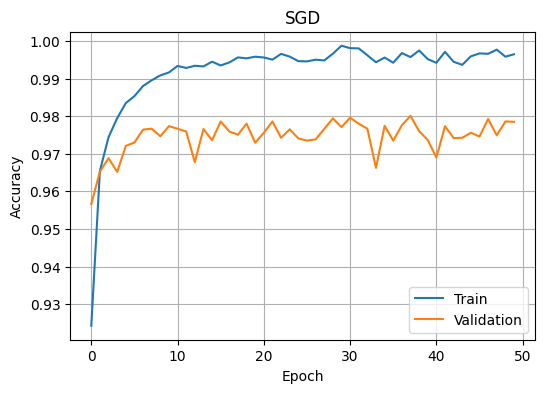

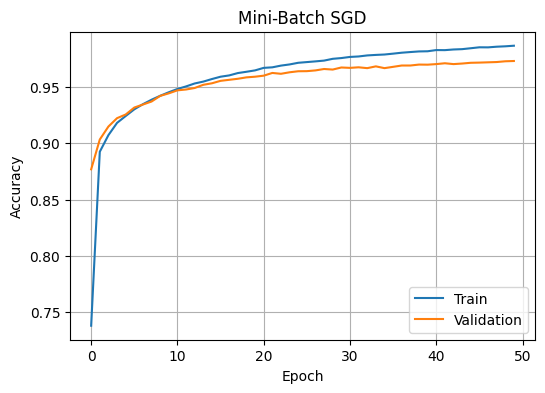

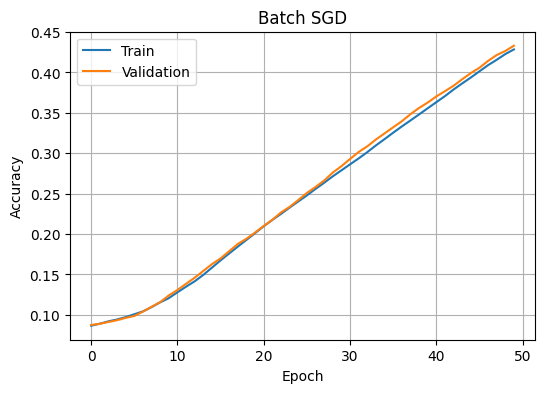

In [11]:
def plot_history(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])
    plt.grid()
    plt.show()

plot_history(history_sgd, "SGD")
plot_history(history_mini, "Mini-Batch SGD")
plot_history(history_batch, "Batch SGD")

In [12]:
model_decay = build_mlp()
model_decay.compile(
    optimizer=SGD(learning_rate=0.01, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_decay = model_decay.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5959 - loss: 1.4100 - val_accuracy: 0.8739 - val_loss: 0.4648
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8862 - loss: 0.4227 - val_accuracy: 0.9038 - val_loss: 0.3415
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9057 - loss: 0.3304 - val_accuracy: 0.9168 - val_loss: 0.2971
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9171 - loss: 0.2876 - val_accuracy: 0.9231 - val_loss: 0.2690
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9244 - loss: 0.2626 - val_accuracy: 0.9277 - val_loss: 0.2496
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9302 - loss: 0.2400 - val_accuracy: 0.9333 - val_loss: 0.2328
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9365 - loss: 0.2182 - val_accuracy: 0.9381 - val_loss: 0.2184
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9404 - loss: 0.2074 - val_accuracy: 0.

In [13]:
model_momentum = build_mlp()
model_momentum.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_momentum = model_momentum.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7872 - loss: 0.7366 - val_accuracy: 0.9375 - val_loss: 0.2118
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9454 - loss: 0.1883 - val_accuracy: 0.9572 - val_loss: 0.1491
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9611 - loss: 0.1323 - val_accuracy: 0.9643 - val_loss: 0.1237
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9690 - loss: 0.1031 - val_accuracy: 0.9675 - val_loss: 0.1079
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9771 - loss: 0.0782 - val_accuracy: 0.9672 - val_loss: 0.1104
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9826 - loss: 0.0620 - val_accuracy: 0.9708 - val_loss: 0.0947
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9847 - loss: 0.0529 - val_accuracy: 0.9731 - val_loss: 0.0923
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9874 - loss: 0.0435 - val_accuracy: 0.

In [14]:
from tensorflow.keras.optimizers import Adam, RMSprop

In [15]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.001),
    "RMSprop": RMSprop(learning_rate=0.001)
}

histories = {}

for name, opt in optimizers.items():
    model = build_mlp()
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    histories[name] = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        verbose=0
    )

In [16]:
model_momentum.save("best_mlp_model.h5")